In [2]:
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
_df = pd.read_csv('./datasets/iris.csv')
df = _df.drop(columns=['Id', 'Species'])
print(df.shape)
print(df.isnull().sum())
df.head()

(150, 4)
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
dtype: int64


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [4]:
x = df
y = _df['Species'].values

In [5]:
# n_components: 분포의 수
model = GaussianMixture(n_components=3, random_state=42)
model.fit(x)

,"n_components n_components: int, default=1The number of mixture components.",3
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [6]:
gmm_labels = model.predict(x)
df['cluster'] = gmm_labels
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,cluster
0,5.1,3.5,1.4,0.2,1
1,4.9,3.0,1.4,0.2,1
2,4.7,3.2,1.3,0.2,1
3,4.6,3.1,1.5,0.2,1
4,5.0,3.6,1.4,0.2,1


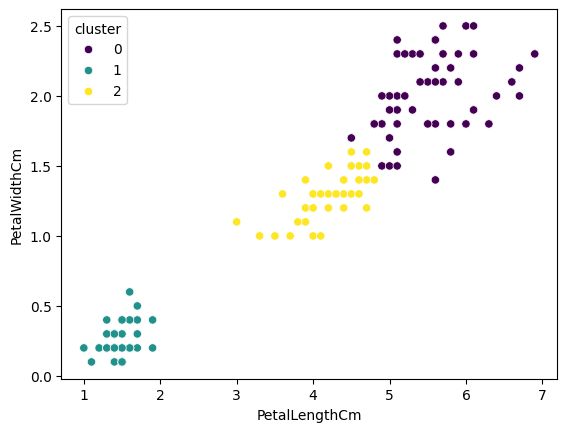

In [7]:
sns.scatterplot(x='PetalLengthCm', y='PetalWidthCm', hue='cluster', data=df, palette='viridis')
plt.show()

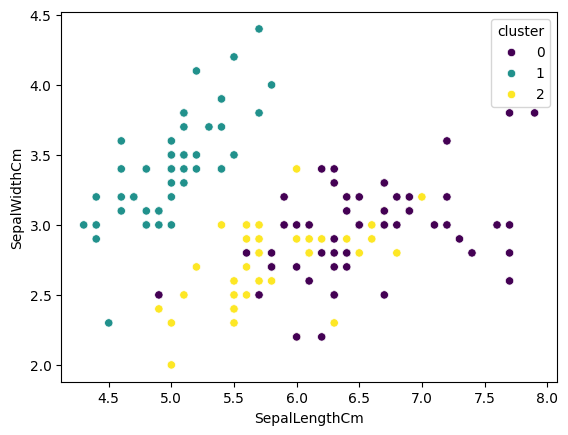

In [8]:
sns.scatterplot(x='SepalLengthCm', y='SepalWidthCm', hue='cluster', data=df, palette='viridis')
plt.show()

In [9]:
silhouette_avg = silhouette_score(x, gmm_labels)
silhouette_avg

0.6628026247124665

In [10]:
# 각 cluster에 어떤 종이 얼마나 들어있는지 확인
# cluster 0 : Iris-virginica(36)
# cluster 1 : Iris-setosa(50)
# cluster 2 : Iris-versicolor(47)
pd.crosstab(y, gmm_labels, rownames=['Species'], colnames=['Cluster'])

Cluster,0,1,2
Species,,,
Iris-setosa,0,50,0
Iris-versicolor,5,0,45
Iris-virginica,50,0,0


In [11]:
# 실제 레이블과 군집 레이블 간의 매핑
# 군집 레이블을 실제 레이블에 매핑 (수동 설정)

# cluster 0, 1, 2 순서에 따른 species 순서 2, 0, 1
species_labels = np.choose(gmm_labels, [2, 0, 1])
df['predicted_species'] = species_labels

In [12]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)
# 'Iris-setosa' → 0, 'Iris-versicolor' → 1, 'Iris-virginica' → 2

cm = confusion_matrix(y_encoded, species_labels)
print("confusion matrix:\n", cm)

confusion matrix:
 [[50  0  0]
 [ 0 45  5]
 [ 0  0 50]]


In [13]:
# silhouette score 활용 최적의 군집 수 계산
# 1에 가장 가까운 값이 최적의 분포 수

silhouette_scores = []

for n_components in range(2, 11):  # 분포 수를 2에서 10까지 변경
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(x)
    gmm_labels = gmm.predict(x)
    score = silhouette_score(x, gmm_labels)
    silhouette_scores.append((n_components, score))

for n_components, score in silhouette_scores:
    print(f"{n_components}: {score}")

2: 0.6272437188670864
3: 0.6833010207356214
4: 0.6127741734171926
5: 0.42750425689578453
6: 0.33915435123494
7: 0.31959290455610917
8: 0.31998526934715255
9: 0.3165919459900594
10: 0.30253803705742216


---

- PCA 차원 축소

In [14]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
_df = pd.read_csv('./datasets/iris.csv').drop(columns=['Id'])
_df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [15]:
df_pca = pca.fit_transform(_df.iloc[:, :-1])
df = pd.DataFrame(df_pca, columns=['pca_comp1', 'pca_comp2'])

df.head()

,pca_comp1,pca_comp2
0,-2.684207,0.326607
1,-2.715391,-0.169557
2,-2.889820,-0.137346
3,-2.746437,-0.311124
4,-2.728593,0.333925


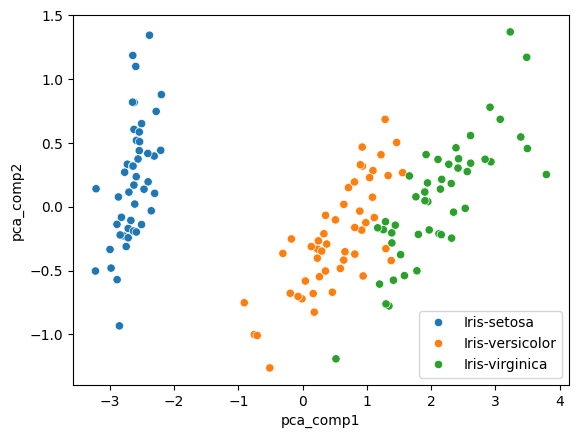

In [16]:
sns.scatterplot(data=df, x='pca_comp1', y='pca_comp2', hue=y)
plt.show()